In [1]:
import pandas as pd  # Load pandas for data handling
import matplotlib.pyplot as plt  # Load matplotlib for plotting
from sklearn.model_selection import train_test_split  # For stratified train/test splitting
from sklearn.naive_bayes import GaussianNB  # Gaussian naive Bayes classifier
from sklearn.metrics import confusion_matrix, accuracy_score  # Evaluation metrics

In [2]:
# Read the CSV file into a data frame
df = pd.read_csv("diabetes_data.csv")

# Print the first few rows to inspect the data
print(df.head())

   glucose  bloodpressure  diabetes
0       40             85         0
1       40             92         0
2       45             63         1
3       45             80         0
4       40             73         1


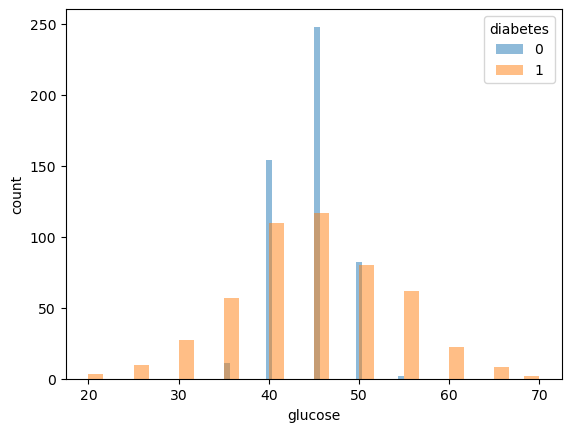

In [3]:
# Draw overlapping, semi-transparent histograms of glucose, colored by diabetes status
fig, ax = plt.subplots()
# Plot glucose histogram for the diabetes = 0 group, semi-transparent
ax.hist(df.loc[df["diabetes"] == 0, "glucose"], bins=30, alpha=0.5, label="0")
# Plot glucose histogram for the diabetes = 1 group, semi-transparent, overlapping the first
ax.hist(df.loc[df["diabetes"] == 1, "glucose"], bins=30, alpha=0.5, label="1")
# Label the x-axis
ax.set_xlabel("glucose")
# Label the y-axis
ax.set_ylabel("count")
# Add a legend distinguishing the two diabetes groups
ax.legend(title="diabetes")
# Display the glucose histogram
plt.show()

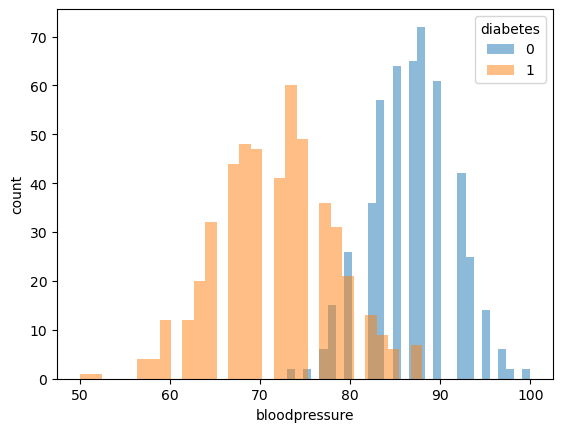

In [4]:
# Draw overlapping, semi-transparent histograms of bloodpressure, colored by diabetes status
fig, ax = plt.subplots()
# Plot bloodpressure histogram for the diabetes = 0 group, semi-transparent
ax.hist(df.loc[df["diabetes"] == 0, "bloodpressure"], bins=30, alpha=0.5, label="0")
# Plot bloodpressure histogram for the diabetes = 1 group, semi-transparent, overlapping the first
ax.hist(df.loc[df["diabetes"] == 1, "bloodpressure"], bins=30, alpha=0.5, label="1")
# Label the x-axis
ax.set_xlabel("bloodpressure")
# Label the y-axis
ax.set_ylabel("count")
# Add a legend distinguishing the two diabetes groups
ax.legend(title="diabetes")
# Display the bloodpressure histogram
plt.show()

In [5]:
# Load the row indices exported from R's stratified split, so both languages use identical rows
train_idx = pd.read_csv("train_indices.csv")["row_index"]
test_idx = pd.read_csv("test_indices.csv")["row_index"]

# R's row indices are 1-based positions in the original CSV; convert to 0-based positions for pandas
train = df.iloc[train_idx.to_numpy() - 1]
test = df.iloc[test_idx.to_numpy() - 1]

# Check class balance (counts and proportions) of diabetes in the training set
print(train["diabetes"].value_counts())
print(train["diabetes"].value_counts(normalize=True))

# Check class balance (counts and proportions) of diabetes in the testing set
print(test["diabetes"].value_counts())
print(test["diabetes"].value_counts(normalize=True))

diabetes
1    373
0    372
Name: count, dtype: int64
diabetes
1    0.500671
0    0.499329
Name: proportion, dtype: float64
diabetes
0    125
1    125
Name: count, dtype: int64
diabetes
0    0.5
1    0.5
Name: proportion, dtype: float64


In [6]:
# Separate predictors (glucose, bloodpressure) from the outcome (diabetes) in the training set
X_train = train[["glucose", "bloodpressure"]]
y_train = train["diabetes"]

# Separate predictors and outcome in the testing set
X_test = test[["glucose", "bloodpressure"]]
y_test = test["diabetes"]

In [9]:
# Create a Gaussian naive Bayes classifier
nb_model = GaussianNB()

# Fit the classifier on the training predictors and outcome
nb_model.fit(X_train, y_train)

# Print the per-class prior probabilities learned by the model
print(nb_model.class_prior_)

# Print the per-class means for each predictor (glucose, bloodpressure)
print(nb_model.theta_)

# Print the per-class variances for each predictor (glucose, bloodpressure)
print(nb_model.var_)

# Generate class predictions for the test set using the fitted model
test_pred = nb_model.predict(X_test)

# Store the predictions as a new column on the test data frame
test = test.copy()
test["pred"] = test_pred

[0.49932886 0.50067114]
[[44.09946237 86.81989247]
 [44.83914209 71.21983914]]
[[14.71322561 20.97024954]
 [76.24758327 37.30823921]]


In [10]:
# Build a confusion matrix comparing true diabetes labels to predicted labels
conf_mat = confusion_matrix(y_test, test_pred)

# Print the confusion matrix
print(conf_mat)

# Compute overall accuracy as the proportion of correct predictions
accuracy = accuracy_score(y_test, test_pred)

# Print the accuracy
print(accuracy)

[[117   8]
 [ 14 111]]
0.912


In [11]:
# Create a new data frame representing a single new patient with glucose and bloodpressure values
new_patient = pd.DataFrame({"glucose": [50], "bloodpressure": [75]})

# Predict the class label (0 = no diabetes, 1 = diabetes) for the new patient
print(nb_model.predict(new_patient))

# Predict class probabilities for the new patient instead of just the class label
print(nb_model.predict_proba(new_patient))

[1]
[[0.04564444 0.95435556]]
